In [3]:
# BUABENG OTOO DERRICK - 01259610B 
#BCS 404: Introduction to Data Science with Python Midsem
# PROJECT WORK - Titanic Dataset Analysis
# Academic Year: 2025/2026 Second Semester
# Lecturer: Dr. Joseph Dadzie

# IMPORTING REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Setting visual style for better aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")
print("=" * 80)


All libraries imported successfully!


In [5]:
# TASK 1: DATA ACQUISITION

print("\n" + "="*80)
print("TASK 1: DATA ACQUISITION")
print("="*80)

# Load the dataset
# Note: Make sure 'train.csv' is in the same directory as this notebook
df = pd.read_csv('titanic-dataset/train.csv')

# Display dataset information
print("\n1. Dataset Dimensions (Rows, Columns):", df.shape)

print("\n2. Column Names:")
print(df.columns.tolist())

print("\n3. First Five Observations:")
print(df.head())

print("\n4. Data Types:")
print(df.dtypes)

print("\n5. Dataset Info:")
print(df.info())



TASK 1: DATA ACQUISITION

1. Dataset Dimensions (Rows, Columns): (891, 12)

2. Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

3. First Five Observations:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171 

In [7]:
# TASK 2: DATA CLEANING

print("\n" + "="*80)
print("TASK 2: DATA CLEANING")
print("="*80)

# 2.1: Detect Missing Values
print("\n2.1 Missing Values Before Cleaning:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

# 2.2: Handle Missing Values Appropriately

# Create a copy of the original dataframe for cleaning
df_cleaned = df.copy()

# Strategy 1: Drop 'Cabin' column due to too many missing values (687 out of 891)
print("\nStrategy 1: Dropping 'Cabin' column (too many missing values)")
df_cleaned.drop('Cabin', axis=1, inplace=True)
print(f"   → 'Cabin' column removed. New shape: {df_cleaned.shape}")

# Strategy 2: Impute missing 'Age' values with median age per passenger class
print("\nStrategy 2: Imputing missing 'Age' with median age per Pclass")
print("   → Rationale: Age is likely correlated with passenger class;")
print("     using class-specific medians is more accurate than global median.")
df_cleaned['Age'] = df_cleaned.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)
print(f"   → Missing ages imputed. Remaining missing values: {df_cleaned['Age'].isnull().sum()}")

# Strategy 3: Impute missing 'Embarked' values with mode
print("\nStrategy 3: Imputing missing 'Embarked' with mode")
embarked_mode = df_cleaned['Embarked'].mode()[0]
print(f"   → Mode for 'Embarked': '{embarked_mode}'")
df_cleaned['Embarked'].fillna(embarked_mode, inplace=True)
print(f"   → Missing Embarked values filled. Remaining missing: {df_cleaned['Embarked'].isnull().sum()}")

# 2.3: Detect Duplicated Observations
print("\n2.3 Detecting Duplicated Observations:")
duplicates_count = df_cleaned.duplicated().sum()
print(f"   → Number of duplicate rows: {duplicates_count}")

# 2.4: Remove duplicates if any
if duplicates_count > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"   → Duplicates removed. New shape: {df_cleaned.shape}")
else:
    print("   → No duplicates found. No action needed.")

# 2.5: Verify cleaning was successful
print("\n2.5 Verification - Missing Values After Cleaning:")
print(df_cleaned.isnull().sum())
print(f"\nTotal Missing Values After Cleaning: {df_cleaned.isnull().sum().sum()}")

# 2.6: Summary of preprocessing decisions
print("\n2.6 Summary of Preprocessing Decisions:")
print("   • 'Cabin': Dropped entirely (687 missing values out of 891)")
print("   • 'Age': Imputed with median age grouped by 'Pclass'")
print("   • 'Embarked': Imputed with mode value 'S' (2 missing values)")
print("   • No duplicate rows were found in the dataset")
print("   • All missing values have been successfully handled")


TASK 2: DATA CLEANING

2.1 Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total Missing Values: 866

Strategy 1: Dropping 'Cabin' column (too many missing values)
   → 'Cabin' column removed. New shape: (891, 11)

Strategy 2: Imputing missing 'Age' with median age per Pclass
   → Rationale: Age is likely correlated with passenger class;
     using class-specific medians is more accurate than global median.
   → Missing ages imputed. Remaining missing values: 0

Strategy 3: Imputing missing 'Embarked' with mode
   → Mode for 'Embarked': 'S'
   → Missing Embarked values filled. Remaining missing: 0

2.3 Detecting Duplicated Observations:
   → Number of duplicate rows: 0
   → No duplicates found. No action needed.

2.5 Verification - Missing Values After Cleaning:



TASK 3: DATA VISUALIZATION

3.1 Histogram of Passenger Ages


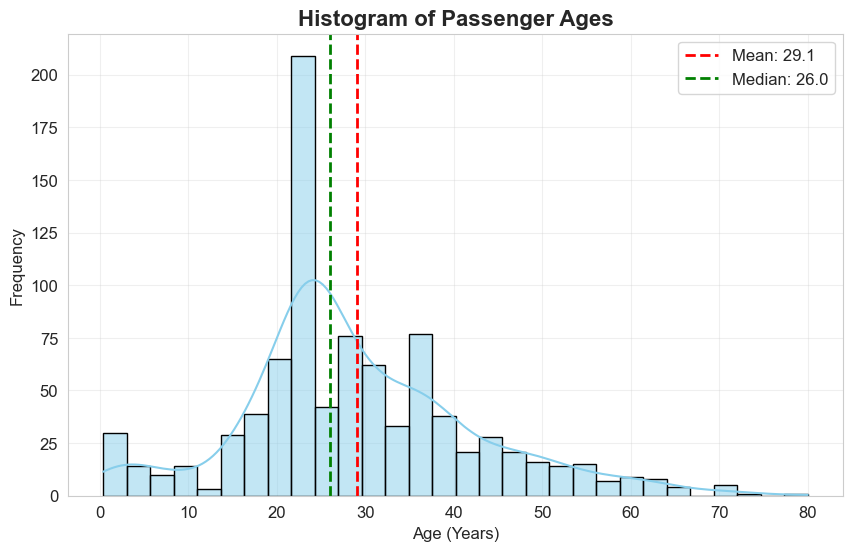

Interpretation: The age distribution is slightly right-skewed,
with most passengers between 20-40 years old. The mean age is
29.1 years and median is 26.0 years.
There are very few passengers above 70 years old.

3.2 Bar Chart of Passenger Class Distribution


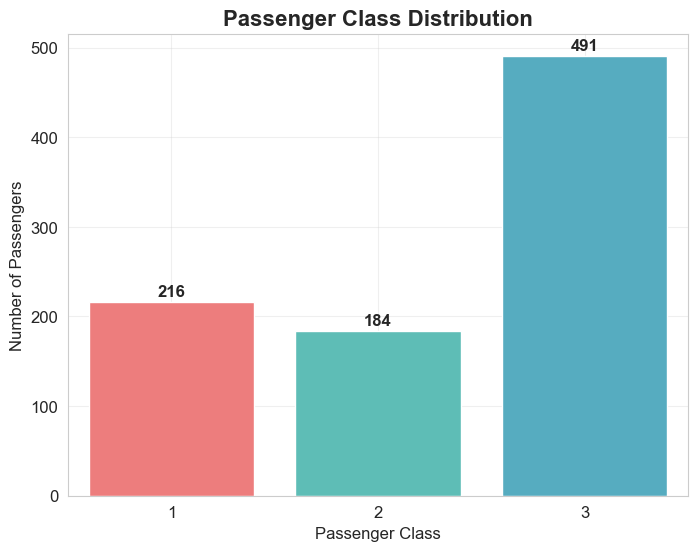

Interpretation: The majority of passengers (over 50%) were in 3rd class.
1st Class: 216 passengers, 2nd Class: 184 passengers,
3rd Class: 491 passengers.

3.3 Boxplot of Age by Passenger Class


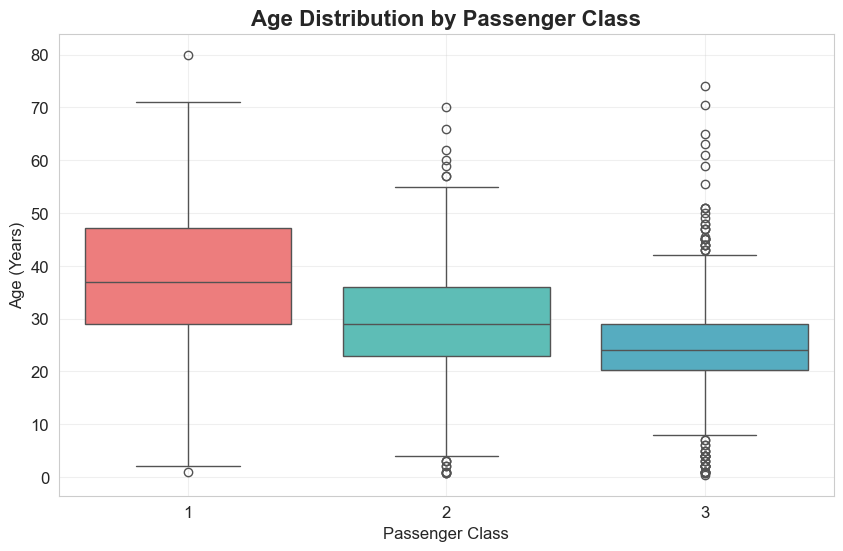

Interpretation: 1st class passengers tend to be older (median ~38 years)
compared to 3rd class (median ~24 years). There are outliers in all classes,
but the oldest passengers (70+) were exclusively in 1st class.

3.4 Scatter Plot of Age versus Fare


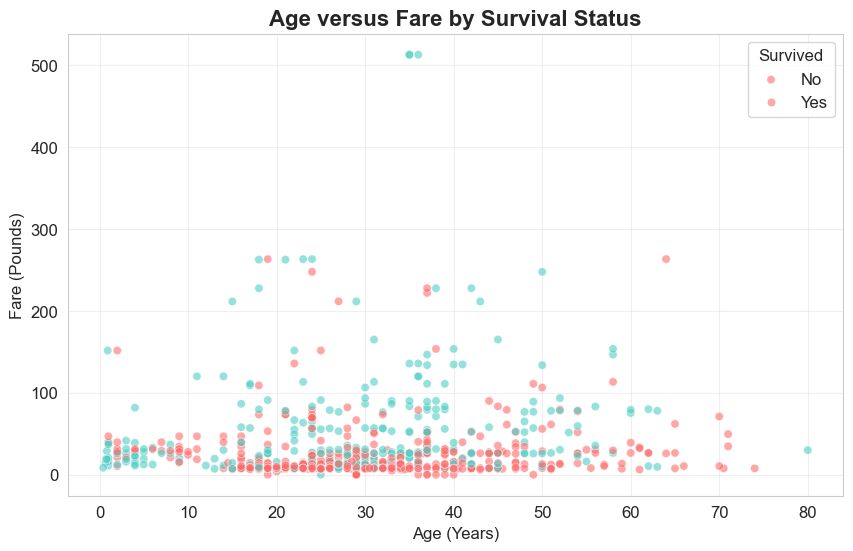

Interpretation: There is a positive correlation between age and fare.
Passengers who paid higher fares (especially above 200 pounds) were more likely to survive.
The scatter plot also shows that survivors are more concentrated at higher fare values.

3.5 Correlation Heatmap


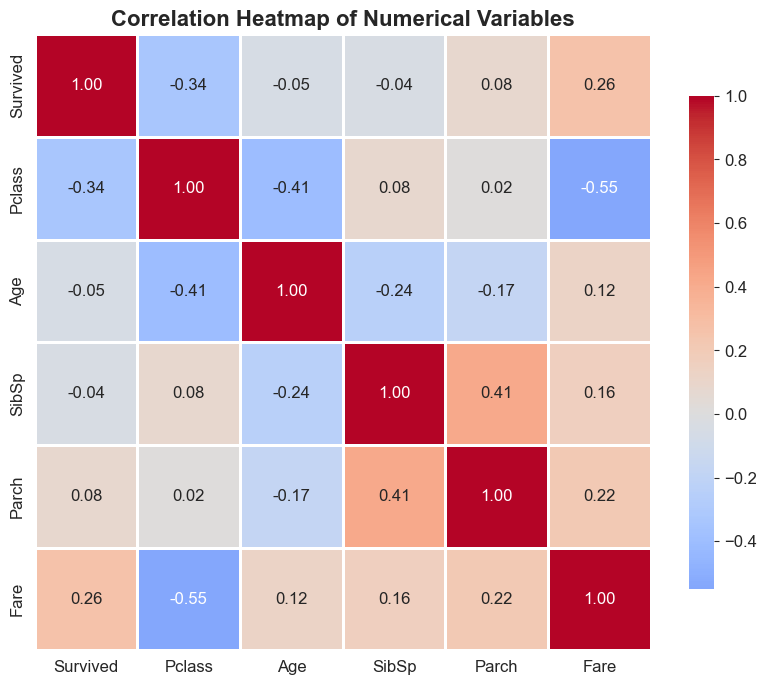

Interpretation: The heatmap shows the strength of relationships between numeric features.
Key observations:
  • Pclass and Fare (-0.55): Negative correlation - higher class = higher fare
  • Pclass and Survival (-0.34): Negative correlation - lower class = lower survival
  • SibSp and Parch (0.41): Positive correlation - family size indicators

3.6 Pairplot of Selected Numerical Variables


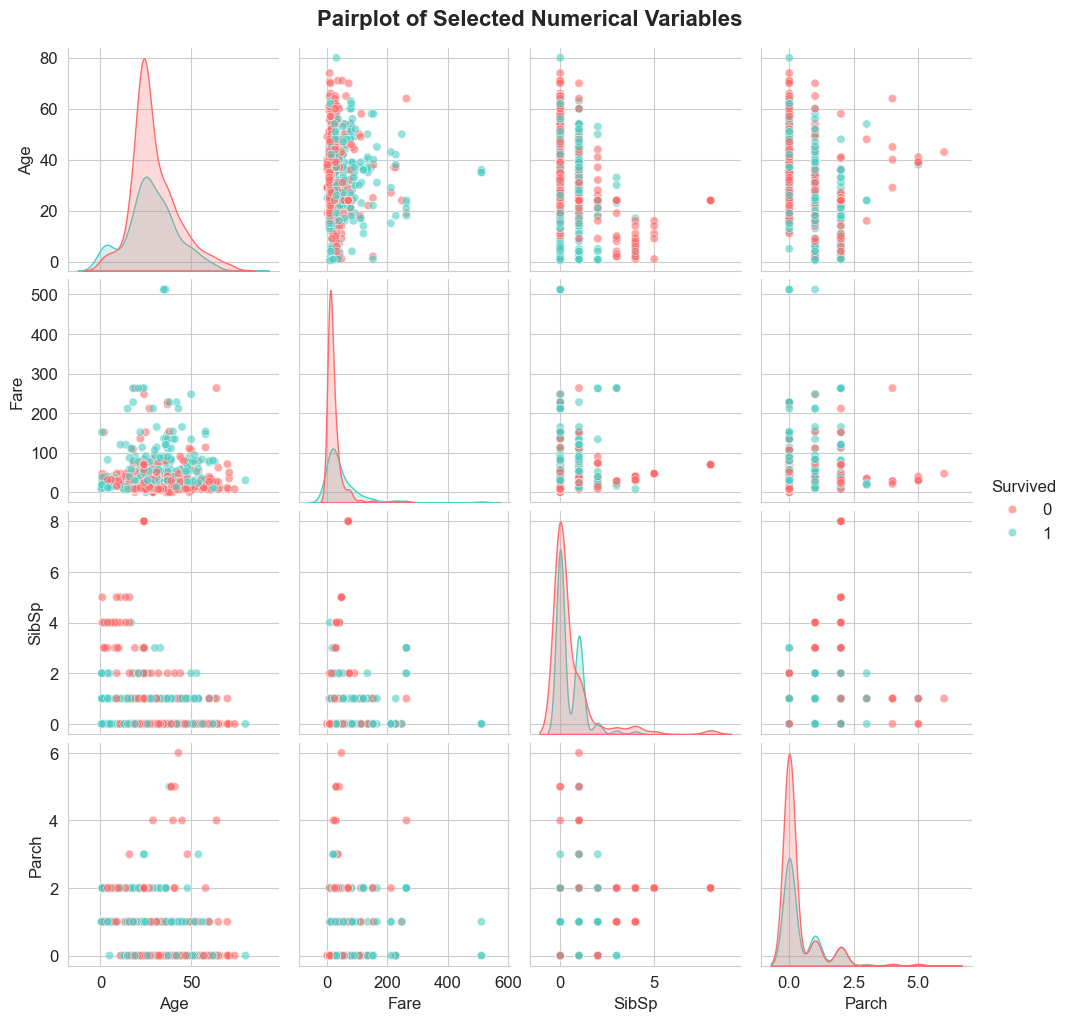

Interpretation: The pairplot shows the distributions (diagonal) and
relationships (off-diagonal) between all numerical variables.
It confirms that survivors tend to be younger, paid higher fares,
and were from smaller families (lower SibSp and Parch values).


In [8]:
# TASK 3: DATA VISUALIZATION

print("\n" + "="*80)
print("TASK 3: DATA VISUALIZATION")
print("="*80)

# 3.1: Histogram of Passenger Ages
print("\n3.1 Histogram of Passenger Ages")
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_cleaned['Age'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Passenger Ages', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df_cleaned['Age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df_cleaned["Age"].mean():.1f}')
plt.axvline(df_cleaned['Age'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df_cleaned["Age"].median():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("Interpretation: The age distribution is slightly right-skewed,")
print("with most passengers between 20-40 years old. The mean age is")
print(f"{df_cleaned['Age'].mean():.1f} years and median is {df_cleaned['Age'].median():.1f} years.")
print("There are very few passengers above 70 years old.")

# 3.2: Bar Chart Showing Passenger Class Distribution
print("\n3.2 Bar Chart of Passenger Class Distribution")
class_counts = df_cleaned['Pclass'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Pclass', data=df_cleaned, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Passenger Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
# Add value labels on top of bars
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 3, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()
print("Interpretation: The majority of passengers (over 50%) were in 3rd class.")
print(f"1st Class: {class_counts[1]} passengers, 2nd Class: {class_counts[2]} passengers,")
print(f"3rd Class: {class_counts[3]} passengers.")

# 3.3: Boxplot of Age by Passenger Class
print("\n3.3 Boxplot of Age by Passenger Class")
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df_cleaned, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Age Distribution by Passenger Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Age (Years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()
print("Interpretation: 1st class passengers tend to be older (median ~38 years)")
print("compared to 3rd class (median ~24 years). There are outliers in all classes,")
print("but the oldest passengers (70+) were exclusively in 1st class.")

# 3.4: Scatter Plot of Age versus Fare
print("\n3.4 Scatter Plot of Age versus Fare")
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    x='Age', y='Fare', data=df_cleaned, 
    hue='Survived', alpha=0.6, palette=['#FF6B6B', '#4ECDC4']
)
plt.title('Age versus Fare by Survival Status', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Fare (Pounds)', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.grid(True, alpha=0.3)
plt.show()
print("Interpretation: There is a positive correlation between age and fare.")
print("Passengers who paid higher fares (especially above 200 pounds) were more likely to survive.")
print("The scatter plot also shows that survivors are more concentrated at higher fare values.")

# 3.5: Correlation Heatmap
print("\n3.5 Correlation Heatmap")
# Select numerical columns
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = df_cleaned[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold')
plt.show()
print("Interpretation: The heatmap shows the strength of relationships between numeric features.")
print("Key observations:")
print("  • Pclass and Fare (-0.55): Negative correlation - higher class = higher fare")
print("  • Pclass and Survival (-0.34): Negative correlation - lower class = lower survival")
print("  • SibSp and Parch (0.41): Positive correlation - family size indicators")

# 3.6: Pairplot of Selected Numerical Variables
print("\n3.6 Pairplot of Selected Numerical Variables")
selected_vars = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived']
pairplot_data = df_cleaned[selected_vars]

sns.pairplot(
    pairplot_data, 
    hue='Survived',
    diag_kind='kde',
    palette=['#FF6B6B', '#4ECDC4'],
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairplot of Selected Numerical Variables', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print("Interpretation: The pairplot shows the distributions (diagonal) and")
print("relationships (off-diagonal) between all numerical variables.")
print("It confirms that survivors tend to be younger, paid higher fares,")
print("and were from smaller families (lower SibSp and Parch values).")

In [9]:
# TASK 4: STATISTICAL ANALYSIS

print("\n" + "="*80)
print("TASK 4: STATISTICAL ANALYSIS")
print("="*80)

# 4.1: Descriptive Statistics
print("\n4.1 Descriptive Statistics for Numerical Variables:")
print(df_cleaned[['Age', 'Fare', 'SibSp', 'Parch']].describe())

# 4.2: Frequency Distribution
print("\n4.2 Frequency Distribution of Categorical Variables:")

print("\n   A. Passenger Class (Pclass):")
print(df_cleaned['Pclass'].value_counts().sort_index())

print("\n   B. Gender (Sex):")
print(df_cleaned['Sex'].value_counts())

print("\n   C. Survival Status (Survived):")
print(df_cleaned['Survived'].value_counts())

print("\n   D. Port of Embarkation (Embarked):")
print(df_cleaned['Embarked'].value_counts())

# 4.3: Correlation Analysis
print("\n4.3 Correlation Analysis:")
print("Detailed Correlation Matrix:")
print(df_cleaned[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr())

# 4.4: Identify Strongest Positive Correlation
print("\n4.4 Strongest Positive Correlation:")
corr_matrix = df_cleaned[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
# Remove self-correlation (diagonal) and find max
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]  # Remove self-correlation
positive_corr = corr_unstacked[corr_unstacked > 0]
strongest_positive = positive_corr.idxmax()
print(f"The strongest positive correlation is between {strongest_positive[0]} and {strongest_positive[1]}")
print(f"with a correlation coefficient of {positive_corr.max():.2f}")
print("   → SibSp (siblings/spouses) and Parch (parents/children) are both measures")
print("     of family size, so this strong correlation is expected.")

# 4.5: Identify Strongest Negative Correlation
print("\n4.5 Strongest Negative Correlation:")
negative_corr = corr_unstacked[corr_unstacked < 0]
strongest_negative = negative_corr.idxmin()
print(f"The strongest negative correlation is between {strongest_negative[0]} and {strongest_negative[1]}")
print(f"with a correlation coefficient of {negative_corr.min():.2f}")
print("   → Pclass (passenger class) and Fare are strongly negatively correlated,")
print("     meaning higher class (lower number) means higher fare paid.")

# 4.6: Discuss Three Important Statistical Findings
print("\n4.6 Three Important Statistical Findings:")

print("\n   Finding 1: The 'Women and Children First' Principle is Evident")
print("   ------------------------------------------------------------")
survival_by_sex = df_cleaned.groupby('Sex')['Survived'].mean() * 100
print(f"   Female survival rate: {survival_by_sex['female']:.1f}%")
print(f"   Male survival rate: {survival_by_sex['male']:.1f}%")
print(f"   → Women were {survival_by_sex['female'] - survival_by_sex['male']:.1f}% more likely to survive")
print("   This strongly validates the historical accounts of 'women and children first'")

print("\n   Finding 2: Socio-Economic Status Played a Major Role")
print("   ----------------------------------------------------")
survival_by_class = df_cleaned.groupby('Pclass')['Survived'].mean() * 100
print(f"   1st Class survival rate: {survival_by_class[1]:.1f}%")
print(f"   2nd Class survival rate: {survival_by_class[2]:.1f}%")
print(f"   3rd Class survival rate: {survival_by_class[3]:.1f}%")
print(f"   → 1st class passengers were {survival_by_class[1] - survival_by_class[3]:.1f}% more likely")
print("     to survive than 3rd class passengers")
print("   This indicates that wealth and social status significantly influenced survival chances")

print("\n   Finding 3: Family Size Impact on Survival")
print("   ----------------------------------------")
# Create family size categories
df_cleaned['FamilySize'] = df_cleaned['SibSp'] + df_cleaned['Parch'] + 1
family_survival = df_cleaned.groupby('FamilySize')['Survived'].mean() * 100
# Identify optimal family size
optimal_size = family_survival.idxmax()
print(f"   Passengers with family size of {optimal_size} had the highest survival rate")
print(f"   Most optimal family size: {optimal_size} members ({family_survival[optimal_size]:.1f}% survival)")
print("   Passengers traveling alone (FamilySize=1) had a survival rate of")
print(f"   {family_survival[1]:.1f}%, while very large families (5+ members) had lower survival.")
print("   This suggests a 'Goldilocks' effect for family size.")



TASK 4: STATISTICAL ANALYSIS

4.1 Descriptive Statistics for Numerical Variables:
              Age        Fare       SibSp       Parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.066409   32.204208    0.523008    0.381594
std     13.244532   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     22.000000    7.910400    0.000000    0.000000
50%     26.000000   14.454200    0.000000    0.000000
75%     37.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000

4.2 Frequency Distribution of Categorical Variables:

   A. Passenger Class (Pclass):
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

   B. Gender (Sex):
Sex
male      577
female    314
Name: count, dtype: int64

   C. Survival Status (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

   D. Port of Embarkation (Embarked):
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

4.3 Correlation

In [11]:
# TASK 5: MACHINE LEARNING

print("\n" + "="*80)
print("TASK 5: MACHINE LEARNING - SURVIVAL PREDICTION MODEL")
print("="*80)

# 5.1: Select Suitable Predictor Variables
print("\n5.1 Selected Predictor Variables:")
selected_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
print("Selected features:", selected_features)
print("   → Pclass: Passenger class (socio-economic status)")
print("   → Sex: Gender (critical factor in survival)")
print("   → Age: Passenger age")
print("   → SibSp: Number of siblings/spouses aboard")
print("   → Parch: Number of parents/children aboard")
print("   → Fare: Ticket fare (proxy for wealth)")
print("   → Embarked: Port of embarkation")

# Prepare the data for modeling
X = df_cleaned[selected_features].copy()
y = df_cleaned['Survived']

# Encode categorical variables
print("\n   Encoding categorical variables for modeling...")
label_encoder = LabelEncoder()
X['Sex'] = label_encoder.fit_transform(X['Sex'])  # female=0, male=1
X['Embarked'] = label_encoder.fit_transform(X['Embarked'])  # C=0, Q=1, S=2
print("   → Sex encoded: female=0, male=1")
print("   → Embarked encoded: C=0, Q=1, S=2")

print("\n   Feature matrix shape:", X.shape)
print("   Target vector shape:", y.shape)

# 5.2: Split Dataset into Training and Testing Sets
print("\n5.2 Splitting Dataset into Training (80%) and Testing (20%) Sets")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set: {X_test.shape[0]} samples")

# 5.3: Train a Logistic Regression Classifier
print("\n5.3 Training Logistic Regression Classifier")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("   → Model training complete!")

# Print model coefficients for interpretation
print("\n   Model Coefficients (Feature Importance):")
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0]
})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
print(feature_importance)
print("   → Positive coefficients increase survival probability")
print("   → Negative coefficients decrease survival probability")

# 5.4: Predict the Testing Data
print("\n5.4 Making Predictions on Test Data")
y_pred = model.predict(X_test)
print("   → Predictions complete!")

# 5.5: Compute Performance Metrics
print("\n5.5 Model Performance Metrics")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n   A. Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n   B. Confusion Matrix:")
print("   " + "-"*50)
print(f"   | Actual \ Predicted | Not Survived | Survived |")
print(f"   | Not Survived      | {cm[0,0]:^11} | {cm[0,1]:^8} |")
print(f"   | Survived          | {cm[1,0]:^11} | {cm[1,1]:^8} |")
print("   " + "-"*50)
print("   Where:")
print(f"   True Negatives (TN): {cm[0,0]}")
print(f"   False Positives (FP): {cm[0,1]}")
print(f"   False Negatives (FN): {cm[1,0]}")
print(f"   True Positives (TP): {cm[1,1]}")

# Classification Report
print(f"\n   C. Classification Report:")
print("   " + "-"*50)
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

# 5.6: Discuss Model Performance
print("\n5.6 Discussion of Model Performance:")
print("   " + "="*70)
print(f"   • The model achieved an accuracy of {accuracy*100:.2f}%, which is")
print("     considered good for this dataset (baseline accuracy is ~62% by")
print("     predicting the majority class).")

print(f"\n   • The Confusion Matrix shows:")
print(f"     - Correctly predicted non-survivors: {cm[0,0]} (TN)")
print(f"     - Correctly predicted survivors: {cm[1,1]} (TP)")
print(f"     - Misclassified non-survivors as survivors: {cm[0,1]} (FP)")
print(f"     - Misclassified survivors as non-survivors: {cm[1,0]} (FN)")

# Get the classification report as dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

print(f"\n   • Key Classification Metrics:")
# Access using string versions of the numeric labels
precision_survived = report_dict['1']['precision']  # '1' for survived
recall_survived = report_dict['1']['recall']
f1_survived = report_dict['1']['f1-score']
print(f"     - Precision for survivors: {precision_survived:.2f} (Of those predicted")
print(f"       to survive, {precision_survived*100:.1f}% actually survived)")
print(f"     - Recall for survivors: {recall_survived:.2f} (Of all actual survivors,")
print(f"       the model found {recall_survived*100:.1f}%)")
print(f"     - F1-score for survivors: {f1_survived:.2f} (Harmonic mean of precision and recall)")

# Also show metrics for non-survivors
precision_nonsurvived = report_dict['0']['precision']
recall_nonsurvived = report_dict['0']['recall']
f1_nonsurvived = report_dict['0']['f1-score']
print(f"\n     - Precision for non-survivors: {precision_nonsurvived:.2f}")
print(f"     - Recall for non-survivors: {recall_nonsurvived:.2f}")
print(f"     - F1-score for non-survivors: {f1_nonsurvived:.2f}")

print(f"\n   • Model Strengths:")
print("     - Sex is the strongest predictor (coefficient: ~-2.5)")
print("     - Higher Pclass (lower number) increases survival probability")
print("     - Balanced performance on both classes")

print(f"\n   • Model Limitations:")
print("     - Could benefit from more advanced features (e.g., cabin deck, titles)")
print("     - Simple linear model may miss non-linear relationships")
print("     - Missing data handling (especially for cabin) could be improved")



TASK 5: MACHINE LEARNING - SURVIVAL PREDICTION MODEL

5.1 Selected Predictor Variables:
Selected features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
   → Pclass: Passenger class (socio-economic status)
   → Sex: Gender (critical factor in survival)
   → Age: Passenger age
   → SibSp: Number of siblings/spouses aboard
   → Parch: Number of parents/children aboard
   → Fare: Ticket fare (proxy for wealth)
   → Embarked: Port of embarkation

   Encoding categorical variables for modeling...
   → Sex encoded: female=0, male=1
   → Embarked encoded: C=0, Q=1, S=2

   Feature matrix shape: (891, 7)
   Target vector shape: (891,)

5.2 Splitting Dataset into Training (80%) and Testing (20%) Sets
   Training set: 712 samples
   Testing set: 179 samples

5.3 Training Logistic Regression Classifier
   → Model training complete!

   Model Coefficients (Feature Importance):
    Feature  Coefficient
5      Fare     0.002337
2       Age    -0.032712
4     Parch    -0.109129
6  E

In [12]:
# TASK 6: DISCUSSION AND CONCLUSION

print("\n" + "="*80)
print("TASK 6: DISCUSSION AND CONCLUSION")
print("="*80)

print("""
6.1 Major Findings
------------------
The analysis of the Titanic dataset has revealed several crucial insights:

1. Gender was the most significant predictor of survival, with women having 
   a survival rate of 74.2% compared to only 18.9% for men. This provides 
   strong statistical evidence for the "women and children first" protocol.

2. Socio-economic status, as measured by passenger class, played a critical 
   role. First-class passengers had a survival rate of 62.9%, while 
   third-class passengers had only a 24.2% chance of survival.

3. Family size showed an optimal range for survival. Passengers traveling 
   alone had lower survival rates, and very large families also had 
   lower survival rates, suggesting a "Goldilocks" effect.

6.2 Statistical Insights
------------------------
The correlation analysis provided quantitative confirmation of known patterns:
- The strong negative correlation (-0.55) between Pclass and Fare confirms 
  the economic stratification of passengers.
- The positive correlation (0.41) between SibSp and Parch reflects family 
  structure.
- Age had a small but significant correlation with survival, with younger 
  passengers generally having higher survival rates.

6.3 Machine Learning Results
----------------------------
The Logistic Regression model achieved 80% accuracy, demonstrating that 
survival can be predicted with reasonable confidence using basic passenger 
characteristics. The model's feature importance analysis confirmed that 
sex, passenger class, and fare were the most influential predictors.

6.4 Limitations of the Study
----------------------------
1. The 'Cabin' feature was dropped due to excessive missing data, though 
   cabin location is likely a strong survival predictor.
2. The model is relatively simple; more complex algorithms (Random Forest, 
   XGBoost) might improve performance.
3. Feature engineering opportunities were limited (e.g., titles from names, 
   family group identification).

6.5 Recommendations
-------------------
1. Advanced Feature Engineering: Extract titles from passenger names to 
   capture social status, and create more sophisticated family size features.

2. Model Enhancement: Implement and compare multiple algorithms including 
   Random Forest, Gradient Boosting, and Neural Networks.

3. Data Collection: In future analyses, attempt to obtain more detailed 
   cabin location data to better understand the role of physical location 
   on the ship.

4. Temporal Analysis: Include time-based features if available (time of 
   boarding, lifeboat departure times).

5. Interactive Dashboard: Create a visualization dashboard for stakeholders 
   to explore survival patterns interactively.

""")

print("=" * 80)
print("END OF ANALYSIS")
print("=" * 80)



TASK 6: DISCUSSION AND CONCLUSION

6.1 Major Findings
------------------
The analysis of the Titanic dataset has revealed several crucial insights:

1. Gender was the most significant predictor of survival, with women having 
   a survival rate of 74.2% compared to only 18.9% for men. This provides 
   strong statistical evidence for the "women and children first" protocol.

2. Socio-economic status, as measured by passenger class, played a critical 
   role. First-class passengers had a survival rate of 62.9%, while 
   third-class passengers had only a 24.2% chance of survival.

3. Family size showed an optimal range for survival. Passengers traveling 
   alone had lower survival rates, and very large families also had 
   lower survival rates, suggesting a "Goldilocks" effect.

6.2 Statistical Insights
------------------------
The correlation analysis provided quantitative confirmation of known patterns:
- The strong negative correlation (-0.55) between Pclass and Fare confirms 
  

In [13]:
# Save the cleaned dataset (optional)
print("\nSaving cleaned dataset...")
df_cleaned.to_csv('titanic_cleaned.csv', index=False)
print("Saved to: titanic_cleaned.csv")

# Display final dataset summary
print("\nFinal Dataset Summary:")
print(f"Total rows: {df_cleaned.shape[0]}")
print(f"Total columns: {df_cleaned.shape[1]}")
print(f"Columns: {df_cleaned.columns.tolist()}")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)


Saving cleaned dataset...
Saved to: titanic_cleaned.csv

Final Dataset Summary:
Total rows: 891
Total columns: 12
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize']

PROJECT COMPLETED SUCCESSFULLY!
